In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE

np.random.seed(42)

In [9]:
n_samples = 120

# --- Technical features (2 clusters) ---
def generate_cluster(mean, std, n):
    return np.random.normal(loc=mean, scale=std, size=(n, len(mean)))

tech_part = np.vstack([
    generate_cluster([30, 50, 10, 2000], [5, 10, 2, 500], n_samples // 2),
    generate_cluster([80, 180, 40, 9000], [5, 10, 2, 500], n_samples // 2)
])

tech_part = np.clip(
    tech_part,
    [10, 20, 5, 1000],
    [100, 200, 50, 10000]
)

# --- Semantic features ---
sem_part = np.zeros((n_samples, 4), dtype=int)

sem_part[:n_samples // 2, 0] = 1  # motor
sem_part[n_samples // 2:, 1] = 1  # turbine

sem_part[:, 2] = np.random.randint(0, 2, n_samples)  # magnet
sem_part[:, 3] = np.random.randint(0, 2, n_samples)  # cooling

# --- Structural features ---
struct_part = np.column_stack([
    np.random.randint(3, 15, n_samples),
    np.random.randint(2, 20, n_samples)
])

# --- DataFrame ---
df = pd.DataFrame(
    np.hstack([tech_part, sem_part, struct_part]),
    columns=[
        'diameter', 'length', 'mass', 'speed',
        'is_motor', 'is_turbine', 'has_magnet', 'has_cooling',
        'num_components', 'num_connections'
    ]
)

# --- FINAL LABELS (balanced: semantic + technical + structural) ---
labels = (
    df["is_motor"] * 2 +
    df["has_magnet"] * 2 +
    (df["diameter"] > 60).astype(int) +
    (df["speed"] > 6000).astype(int) +
    (df["num_components"] > 8).astype(int)
).astype(int).values

print("Label distribution:", np.bincount(labels))

Label distribution: [ 0  0 36 23 34 27]


In [10]:
def build_features(df):
    tech = df[['diameter', 'length', 'mass', 'speed']].values
    semantic = df[['is_motor', 'is_turbine', 'has_magnet', 'has_cooling']].values
    structural = df[['num_components', 'num_connections']].values
    return tech, semantic, structural

tech, semantic, structural = build_features(df)

tech_scaled = StandardScaler().fit_transform(tech)
struct_scaled = StandardScaler().fit_transform(structural)

In [11]:
def cosine_sim(X):
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0.0)
    return S

def semantic_sim(X):
    D = pairwise_distances(X, metric='jaccard')
    S = 1 - D
    np.fill_diagonal(S, 0.0)
    return S

def structural_sim(X):
    S = cosine_similarity(X)
    np.fill_diagonal(S, 0.0)
    return S

S_cos = cosine_sim(tech_scaled)
S_sem = semantic_sim(semantic)
S_struct = structural_sim(struct_scaled)

/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [12]:
def normalize(S):
    S_min = S.min()
    S_max = S.max()
    if S_max - S_min == 0:
        return np.zeros_like(S)
    return (S - S_min) / (S_max - S_min)

S_cos = normalize(S_cos)
S_sem = normalize(S_sem)
S_struct = normalize(S_struct)

In [13]:
def hybrid_sim(S_tech, S_sem, S_struct, a, b, g):
    return a * S_sem + b * S_tech + g * S_struct

In [14]:
def precision_at_k(sim_matrix, labels, k=5):
    n = sim_matrix.shape[0]
    scores = []

    for i in range(n):
        sims = sim_matrix[i]
        idx = np.argsort(sims)[::-1][:k]
        relevant = (labels[idx] == labels[i]).sum()
        scores.append(relevant / k)

    return np.mean(scores)


def mean_reciprocal_rank(sim_matrix, labels):
    rr = []

    for i in range(len(labels)):
        sims = sim_matrix[i]
        idx = np.argsort(sims)[::-1]

        for rank, j in enumerate(idx, start=1):
            if labels[j] == labels[i]:
                rr.append(1 / rank)
                break

    return np.mean(rr)

In [15]:
best_score = -1
best_weights = (0.4, 0.4, 0.2)

for a in np.linspace(0.3, 0.6, 7):
    for b in np.linspace(0.3, 0.6, 7):
        g = 1 - (a + b)
        if g < 0:
            continue

        S_h = hybrid_sim(S_cos, S_sem, S_struct, a, b, g)
        score = precision_at_k(S_h, labels, k=5)

        if score > best_score:
            best_score = score
            best_weights = (a, b, g)

print("Best weights:", best_weights)
print("Best Precision@5:", best_score)

Best weights: (np.float64(0.39999999999999997), np.float64(0.35), np.float64(0.25))
Best Precision@5: 0.8633333333333333


In [16]:
a, b, g = best_weights

S_hybrid = hybrid_sim(S_cos, S_sem, S_struct, a, b, g)

methods = {
    "Technical": S_cos,
    "Semantic": S_sem,
    "Structural": S_struct,
    "Hybrid": S_hybrid,
}

K_list = [3, 5, 10]

results = {k: {} for k in K_list}
mrr = {}

for name, S in methods.items():
    for k in K_list:
        results[k][name] = precision_at_k(S, labels, k)
    mrr[name] = mean_reciprocal_rank(S, labels)

print("Precision@K:")
for k in K_list:
    print(f"K={k}:", results[k])

print("\nMRR:", mrr)

Precision@K:
K=3: {'Technical': np.float64(0.2638888888888889), 'Semantic': np.float64(0.5666666666666667), 'Structural': np.float64(0.5), 'Hybrid': np.float64(0.8861111111111111)}
K=5: {'Technical': np.float64(0.24500000000000002), 'Semantic': np.float64(0.56), 'Structural': np.float64(0.49833333333333335), 'Hybrid': np.float64(0.8633333333333333)}
K=10: {'Technical': np.float64(0.245), 'Semantic': np.float64(0.5525000000000001), 'Structural': np.float64(0.4633333333333333), 'Hybrid': np.float64(0.7316666666666668)}

MRR: {'Technical': np.float64(0.49675456816046054), 'Semantic': np.float64(0.7200694444444444), 'Structural': np.float64(0.6979166666666666), 'Hybrid': np.float64(0.9487698412698413)}


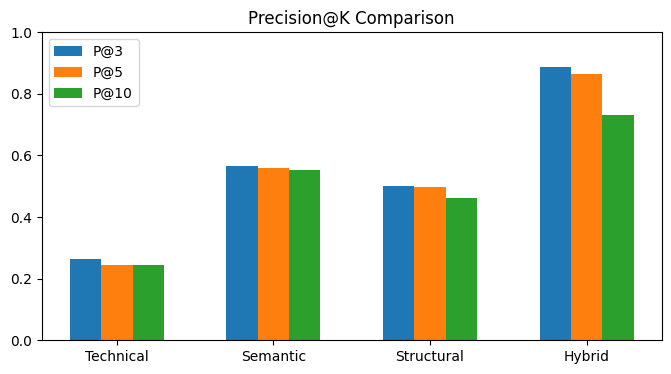

In [17]:
labels_methods = list(methods.keys())
x = np.arange(len(labels_methods))
width = 0.2

plt.figure(figsize=(8,4))

for i, k in enumerate(K_list):
    vals = [results[k][m] for m in labels_methods]
    plt.bar(x + (i-1)*width, vals, width=width, label=f'P@{k}')

plt.xticks(x, labels_methods)
plt.ylim(0,1)
plt.title("Precision@K Comparison")
plt.legend()
plt.show()

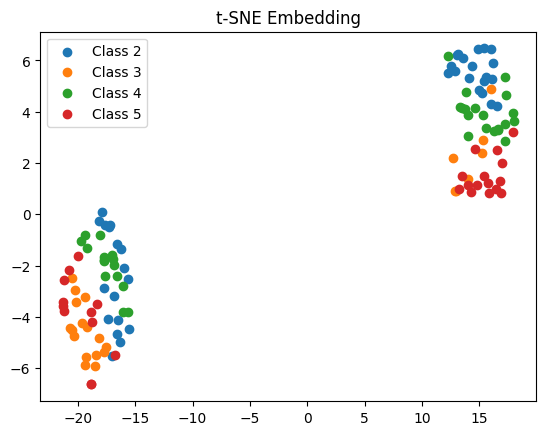

In [18]:
combined = np.hstack([tech_scaled, semantic, struct_scaled])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(combined)

plt.figure()

for lbl in np.unique(labels):
    idx = labels == lbl
    plt.scatter(X_2d[idx,0], X_2d[idx,1], label=f"Class {lbl}")

plt.legend()
plt.title("t-SNE Embedding")
plt.show()

In [19]:
query_idx = 0
sims = S_hybrid[query_idx]
top_idx = np.argsort(sims)[::-1][:5]

print("Query label:", labels[query_idx])
print("Top labels:", labels[top_idx])

Query label: 2
Top labels: [2 2 2 2 2]
